In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Настройка отображения графиков
%matplotlib inline
plt.rcParams["figure.dpi"] = 100

### Функция расчёта метрик регрессии из ПЗ 1

In [2]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

### Общая функция для всего задания

In [3]:
def analyze_sheet(df, x_col, y_col, sheet_name):
    """
    Выполняет полный цикл анализа линейной регрессии для одного листа:
    1) читает данные (уже переданные как df)
    2) строит линейную регрессию
    3) выводит уравнение
    4) рисует графики y(x) и y vs y_pred
    5) считает метрики RMSE, MSE, MAE, R2
    """
    print("=" * 70)
    print(f"ЛИСТ: {sheet_name}")
    print("=" * 70)

    # ---- 1) Данные ----
    data = df[[x_col, y_col]].dropna().copy()
    data.columns = ["X", "Y"]
    print(f"Количество наблюдений: {len(data)}")
    print(data.head(), "\n")

    X = data[["X"]].values   # 2D массив для sklearn
    y = data["Y"].values

    # ---- 2) Линейная регрессия ----
    model = LinearRegression()
    model.fit(X, y)

    # ---- 3) Уравнение регрессии ----
    k = model.coef_[0]
    b = model.intercept_
    print(f"Уравнение линейной регрессии: Y = {k:.6f} * X + ({b:.6f})")
    print(f"Коэффициент детерминации R^2 (sklearn): {model.score(X, y):.6f}\n")

    # ---- 4) Предсказания и графики ----
    y_pred = model.predict(X)

    # 4.1 График y(x) с линией регрессии
    plt.figure(figsize=(8, 5))
    plt.scatter(data["X"], data["Y"], color="tab:blue", alpha=0.6,
                s=30, label="Исходные данные")
    x_line = np.linspace(data["X"].min(), data["X"].max(), 200).reshape(-1, 1)
    y_line = model.predict(x_line)
    plt.plot(x_line, y_line, color="tab:red", lw=2, label="Линейная регрессия")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Зависимость Y(X) — лист {sheet_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4.2 График y_true vs y_pred (в стиле задания)
    df_reg = pd.DataFrame({
        "Y_true": y,
        "Y_pred": y_pred,
        "model": "LinReg",
        "part": "train"
    })

    plt.figure(figsize=(8, 8))

    markers = {"train": "o", "test": "^"}
    colors = {"LinReg": "tab:blue", "Polynominal Reg": "tab:orange"}

    for (mdl, part), group in df_reg.groupby(["model", "part"]):
        plt.scatter(
            group["Y_true"], group["Y_pred"],
            alpha=0.4, s=18,
            marker=markers[part],
            color=colors[mdl],
            label=f"{mdl} | {part}"
        )

    lims = [df_reg["Y_true"].min(), df_reg["Y_true"].max()]
    plt.plot(lims, lims, "k--", lw=1.5, label="y = x (идеал)")

    plt.xlabel("Y_true")
    plt.ylabel("Y_pred")
    plt.title(f"Y_true vs Y_pred — лист {sheet_name}")
    plt.legend(loc="upper left", fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ---- 5) Метрики ----
    metrics = regression_metrics(y, y_pred)
    print("Метрики качества:")
    for name, value in metrics.items():
        print(f"  {name:5s} = {value:.6f}")
    print()

    return {"sheet": sheet_name, "equation": (k, b), **metrics}

### Обработка листа LinReg1

Столбцы LinReg1: ['Масса (X)', 'Сила тяжести(Y)']
ЛИСТ: LinReg1
Количество наблюдений: 15
   X      Y
0  4  39.24
1  5  49.05
2  6  58.86
3  7  68.67
4  8  78.48 

Уравнение линейной регрессии: Y = 9.810000 * X + (0.000000)
Коэффициент детерминации R^2 (sklearn): 1.000000



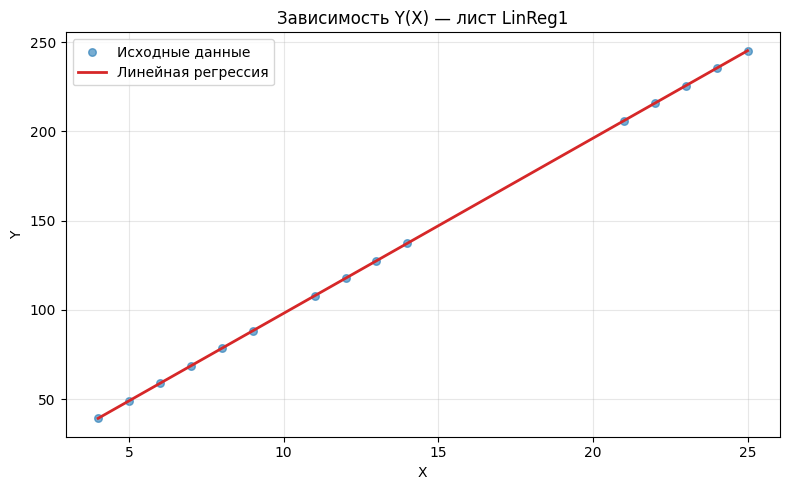

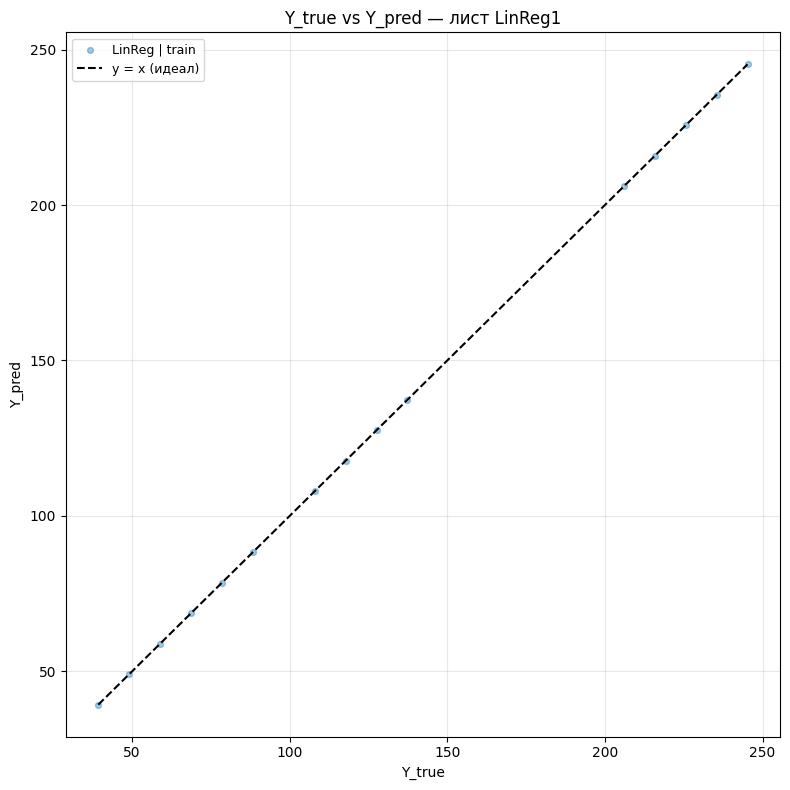

Метрики качества:
  MAE   = 0.000000
  MSE   = 0.000000
  RMSE  = 0.000000
  R2    = 1.000000



In [4]:
# Читаем первый лист
df1 = pd.read_excel("ПЗ 2. LinReg.xlsx", sheet_name="LinReg1")

# Столбцы: A = Масса (X), B = Сила тяжести (Y)
# В файле B — это формула =A*9.81, но при чтении openpyxl/pandas
# значения будут уже вычислены (если файл сохранён Excel).
# Проверим названия столбцов:
print("Столбцы LinReg1:", df1.columns.tolist())

# Переименуем для удобства (первая строка — заголовки)
df1.columns = ["X", "Y"]
# Убираем строку-заголовок, если она попала в данные
df1 = df1[pd.to_numeric(df1["X"], errors="coerce").notna()].copy()
df1["X"] = pd.to_numeric(df1["X"])
df1["Y"] = pd.to_numeric(df1["Y"])

result1 = analyze_sheet(df1, "X", "Y", "LinReg1")

### Обработка листа LinReg2

Столбцы LinReg2: ['Unnamed: 0', 'Наблюдения НЛО в Техасе (случаи наблюдения НЛО) (X)', 'Расстояние между Ураном и Сатурном (расстояние между планетами в а.е.) (Y)\n']
   Unnamed: 0  Наблюдения НЛО в Техасе (случаи наблюдения НЛО) (X)  \
0        1975                                                 21     
1        1976                                                 17     
2        1977                                                 16     
3        1978                                                 23     
4        1979                                                 14     

   Расстояние между Ураном и Сатурном (расстояние между планетами в а.е.) (Y)\n  
0                                            21.8994                             
1                                            20.7485                             
2                                            19.5426                             
3                                            18.2985                             
4 

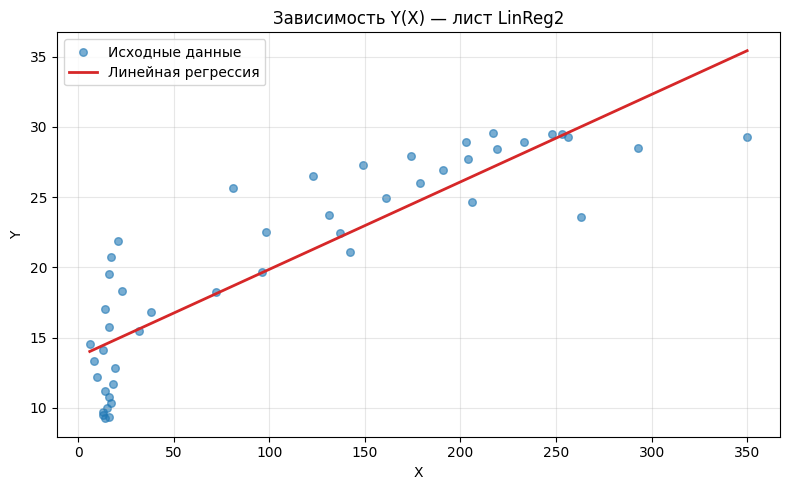

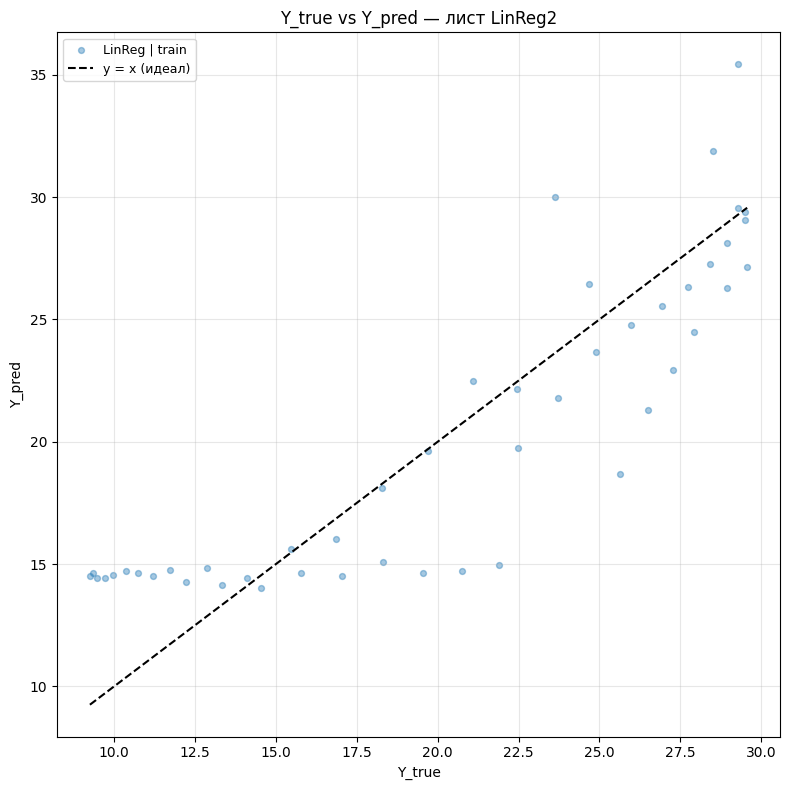

Метрики качества:
  MAE   = 2.728148
  MSE   = 11.692031
  RMSE  = 3.419361
  R2    = 0.763222



In [6]:
# Читаем второй лист. Заголовки в файле на первой строке,
# но там есть пустая колонка-индекс (лет). Учтём это.
df2 = pd.read_excel("ПЗ 2. LinReg.xlsx", sheet_name="LinReg2", header=0)

print("Столбцы LinReg2:", df2.columns.tolist())
print(df2.head())

# В файле: первый столбец — год (индекс), второй — X, третий — Y.
# Переименуем по позициям, чтобы не зависеть от длинных имён.
df2 = df2.iloc[:, :3]
df2.columns = ["Year", "X", "Y"]

# Приводим к числам
df2 = df2.apply(pd.to_numeric, errors="coerce").dropna()

result2 = analyze_sheet(df2, "X", "Y", "LinReg2")

### Сводная таблица

In [11]:
summary = pd.DataFrame([
    {"Лист": result1["sheet"],
     "b1": result1["equation"][0], "b0": result1["equation"][1],
     "MAE": result1["MAE"], "MSE": result1["MSE"],
     "RMSE": result1["RMSE"], "R2": result1["R2"]},
    {"Лист": result2["sheet"],
     "b1": result2["equation"][0], "b0": result2["equation"][1],
     "MAE": result2["MAE"], "MSE": result2["MSE"],
     "RMSE": result2["RMSE"], "R2": result2["R2"]},
])

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
#print(summary.to_string(index=False))
summary

,Лист,b1,b0,MAE,MSE,RMSE,R2
0,LinReg1,9.8100,0.0000,0.0000,0.0000,0.0000,1.0000
1,LinReg2,0.0623,13.6392,2.7281,11.6920,3.4194,0.7632
